# prediksi impor minyak mentah dari Dunia ke AS.


## Pendahuluan

Konsumsi energi dunia semakin meningkat seiring dengan pertumbuhan populasi dan industrialisasi. Minyak mentah merupakan salah satu sumber energi utama yang sangat penting bagi perekonomian global, terutama di negara-negara maju seperti Amerika Serikat. Impor minyak mentah menjadi salah satu indikator utama untuk mengetahui tingkat ketergantungan suatu negara terhadap sumber energi luar negeri, dan juga sebagai dasar untuk merumuskan kebijakan energi yang lebih baik. Data historis impor minyak mentah dari berbagai negara ke Amerika Serikat memberikan gambaran tentang tren kebutuhan energi dan hubungan perdagangan internasional di sektor energi.

Dalam penelitian ini, kami akan menganalisis tren impor minyak mentah Amerika Serikat dari berbagai negara, menggunakan data bulanan dalam ribuan barel. Pendekatan analisis menggunakan metode regresi untuk memprediksi pola impor di masa mendatang berdasarkan data historis yang ada. Hasil dari penelitian ini diharapkan dapat memberikan kontribusi dalam pengambilan kebijakan terkait energi di Amerika Serikat, khususnya dalam konteks ketahanan energi dan diversifikasi sumber impor.

### 1. Latar Belakang

Sejak dekade terakhir, Amerika Serikat telah berusaha untuk mengurangi ketergantungannya pada impor minyak mentah melalui peningkatan produksi domestik serta penggunaan energi alternatif. Meskipun demikian, impor minyak mentah tetap menjadi bagian penting dalam memenuhi kebutuhan energi nasional. Fluktuasi harga minyak global, kondisi geopolitik, serta perubahan dalam kebijakan energi domestik dan internasional memengaruhi volume impor minyak mentah. Dengan demikian, penting untuk memahami tren impor ini agar dapat mengantisipasi perubahan di masa depan serta menyusun strategi yang tepat untuk menjaga ketahanan energi.

Data impor minyak mentah memberikan wawasan tentang dinamika pasar energi dan bagaimana Amerika Serikat menyesuaikan kebutuhan energinya dengan pasokan global. Analisis tren impor minyak mentah juga dapat membantu dalam merumuskan kebijakan ekonomi dan lingkungan yang lebih baik, seperti pengurangan emisi karbon dan peralihan ke energi terbarukan.

### 2. Tujuan

1. Menganalisis tren impor minyak mentah ke Amerika Serikat dari berbagai negara.
2. Membuat prediksi terhadap volume impor minyak mentah di masa depan menggunakan metode regresi


### 3. Rumusan Masalah

1. Bagaimana tren impor minyak mentah ke Amerika Serikat dari tahun ke tahun?

2. Bagaimana prediksi volume impor minyak mentah di masa mendatang berdasarkan data historis?


## Pembahasan

### 1. Data Understanding

#### Pengumpulan Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import pandas as pd

Mounted at /content/drive


In [2]:
data = pd.read_csv("/content/drive/My Drive/psd/tugas/dataset/Imports Oil.csv")
data.head()

,Date and Month,Crude oil imports from the World to the US (a thousand barrels)
0,2009 01,317275
1,2009 02,262339
2,2009 03,303897
3,2009 04,285934
4,2009 05,281147


##### Struktur Data:

1. Date and Month : Menunjukkan kapan impor minyak mentah terjadi, dengan format tahun dan bulan (misalnya, "2009 01" untuk Januari 2009).
2. Crude oil imports from the World to the US (a thousand barrels) : Volume minyak mentah yang diimpor ke AS dalam ribuan barel untuk setiap bulan yang bersangkutan. Angka ini menggambarkan total impor dari seluruh dunia ke Amerika Serikat.

#### 2. Data Preprocessing

Pada bagian ini dataset akan diproses sebelum digunakan untuk membangun model. Dataset akan melalui data cleaning, pendeteksian outlier, dan pendeteksian missing value.

In [3]:
# Tahap 1: Pembersihan nama kolom dari spasi yang tidak perlu
data.columns = data.columns.str.strip()

In [4]:
# Tahap 2: Pendeteksian nilai yang hilang (missing values)
missing_values = data.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing_values)

Jumlah missing value per kolom:
Date and Month                                                     0
Crude oil imports from the World to the US (a thousand barrels)    0
dtype: int64


In [5]:
# Tahap 3: Pendeteksian Outlier menggunakan metode IQR
# Menghitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
Q1 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.25)
Q3 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi nilai outlier
outliers = data[(data['Crude oil imports from the World to the US (a thousand barrels)'] < lower_bound) |
                (data['Crude oil imports from the World to the US (a thousand barrels)'] > upper_bound)]

# Menampilkan hasil deteksi outlier
if outliers.empty:
    print("Tidak ada outlier yang terdeteksi.")
else:
    print("Outlier yang terdeteksi:")
    print(outliers)

Tidak ada outlier yang terdeteksi.


In [6]:
# Tahap 1: Pembersihan nama kolom dari spasi yang tidak perlu
data.columns = data.columns.str.strip()

# Tahap 2: Pendeteksian nilai yang hilang (missing values)
missing_values = data.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing_values)

# Tahap 3: Pendeteksian Outlier menggunakan metode IQR
# Menghitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
Q1 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.25)
Q3 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi nilai outlier
outliers = data[(data['Crude oil imports from the World to the US (a thousand barrels)'] < lower_bound) |
                (data['Crude oil imports from the World to the US (a thousand barrels)'] > upper_bound)]

# Menampilkan hasil deteksi outlier
if outliers.empty:
    print("Tidak ada outlier yang terdeteksi.")
else:
    print("Outlier yang terdeteksi:")
    print(outliers)


Jumlah missing value per kolom:
Date and Month                                                     0
Crude oil imports from the World to the US (a thousand barrels)    0
dtype: int64
Tidak ada outlier yang terdeteksi.


In [7]:
# Menghitung matriks korelasi
correlation_matrix = data[['Crude oil imports from the World to the US (a thousand barrels)']].corr()

# Menampilkan matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)


Matriks Korelasi:
                                                    Crude oil imports from the World to the US (a thousand barrels)
Crude oil imports from the World to the US (a t...                                                1.0              


#### Sliding Window

supervace
mempelajari poroses pebetukan datset asupervice
regresi libier
hitug manual dgn 2 input 2 bulan sebe;umnya dan 1 out


In [42]:
import pandas as pd

# Fungsi untuk membuat sliding window
def create_sliding_window(data, window_size=4):
    # Mengambil data impor minyak mentah dan tanggal
    oil_imports = data['Crude oil imports from the World to the US (a thousand barrels)']
    dates = data['Date and Month']

    # Membuat list untuk menampung windows
    windows = []
    window_dates = []

    # Loop untuk membuat sliding window
    for i in range(len(oil_imports) - window_size + 2):
        windows.append(oil_imports[i:i + window_size].values)
        window_dates.append(dates[i + window_size - 1])  # Ambil tanggal akhir dari window

    # Membuat DataFrame dengan index berupa tanggal
    df_sliding_windows = pd.DataFrame(windows, columns=[f'Window_{i+1}' for i in range(window_size)], index=window_dates)
    df_sliding_windows.index.name = 'Date'  # Menamai index
    return df_sliding_windows

# Membuat sliding window dengan ukuran 3
df_sliding_windows = create_sliding_window(data, window_size=4)

# Menampilkan DataFrame
print(df_sliding_windows)  # Menampilkan contoh 5 baris pertama dari sliding windows


KeyError: 'Crude oil imports from the World to the US (a thousand barrels)'

In [9]:
print(df_sliding_windows.index)  # Untuk memastikan index

Index(['2009 04 ', '2009 05 ', '2009 06 ', '2009 07 ', '2009 08 ', '2009 09 ',
       '2009 10 ', '2009 11 ', '2009 12 ', '2010 01 ',
       ...
       '2020 04 ', '2020 05 ', '2020 06 ', '2020 07 ', '2020 08 ', '2020 09 ',
       '2020 10 ', '2020 11 ', '2020 12 ', '2021 01 '],
      dtype='object', name='Date', length=142)


Fungsi create_sliding_window:
window_size: Menentukan ukuran jendela
Looping digunakan untuk mengambil subset data dalam ukuran jendela yang ditentukan, dan jendela bergerak maju satu data dalam setiap iterasi.

#### Visualisasi data

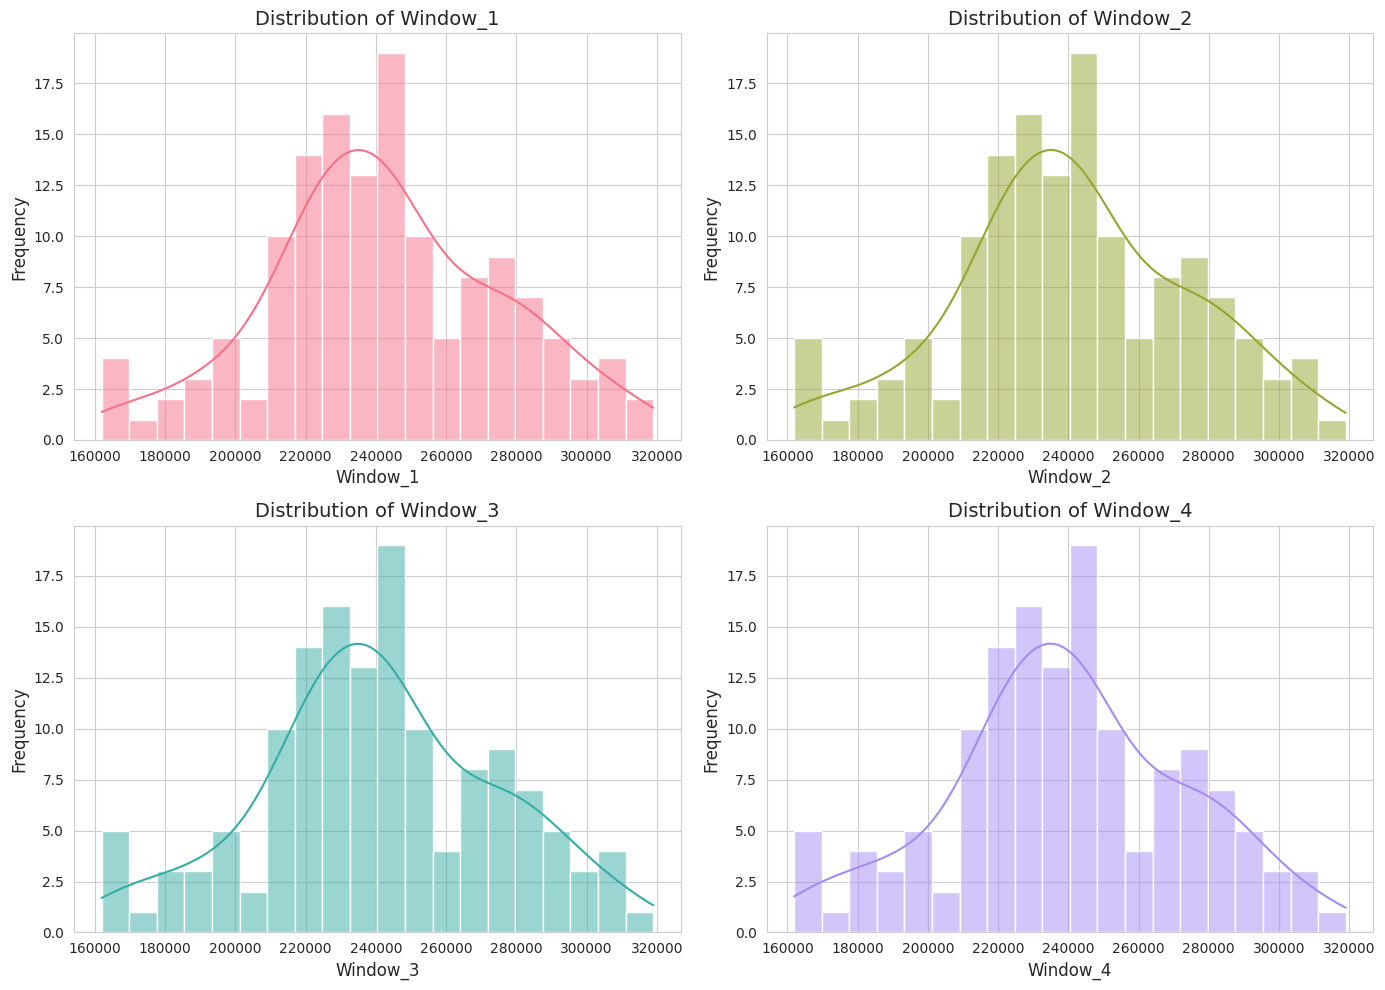

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengambil semua kolom fitur
features = list(df_sliding_windows.columns)

# Menghitung jumlah subplot yang diperlukan
num_features = len(features)
num_rows = (num_features + 1) // 2  # Pembulatan ke atas untuk jumlah baris

# Mengatur gaya seaborn untuk tampilan lebih menarik
sns.set_style("whitegrid")

# Membuat subplot sesuai dengan jumlah fitur
fig, axs = plt.subplots(num_rows, 2, figsize=(14, num_rows * 5))

# Membuat palet warna yang berbeda untuk setiap histogram
colors = sns.color_palette("husl", num_features)

# Melakukan plotting untuk setiap fitur
for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    sns.histplot(df_sliding_windows[feature], bins=20, color=colors[i], ax=axs[row, col], kde=True)
    axs[row, col].set_title(f'Distribution of {feature}', fontsize=14)
    axs[row, col].set_xlabel(feature, fontsize=12)
    axs[row, col].set_ylabel('Frequency', fontsize=12)
    axs[row, col].tick_params(axis='both', which='major', labelsize=10)

# Menghapus subplot yang tidak terpakai jika jumlah fitur ganjil
if num_features % 2 == 1:
    fig.delaxes(axs[num_rows - 1, 1])

# Menyesuaikan layout agar tidak saling tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()


<Axes: xlabel='Date'>

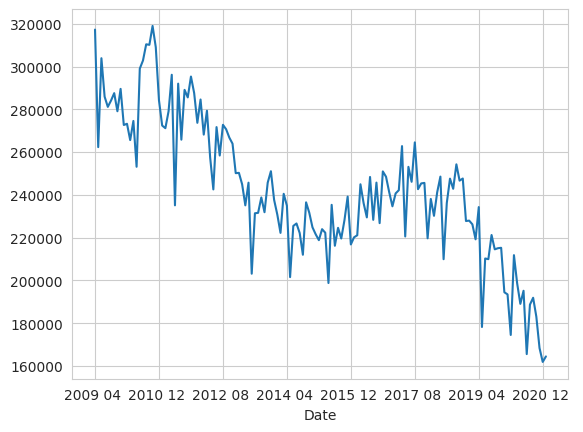

In [11]:
df_sliding_windows['Window_1'].plot()

#### deteksi missing value

In [12]:
print(df_sliding_windows.isnull().sum())

Window_1    0
Window_2    0
Window_3    0
Window_4    0
dtype: int64


#### Pendeteksian Outlier

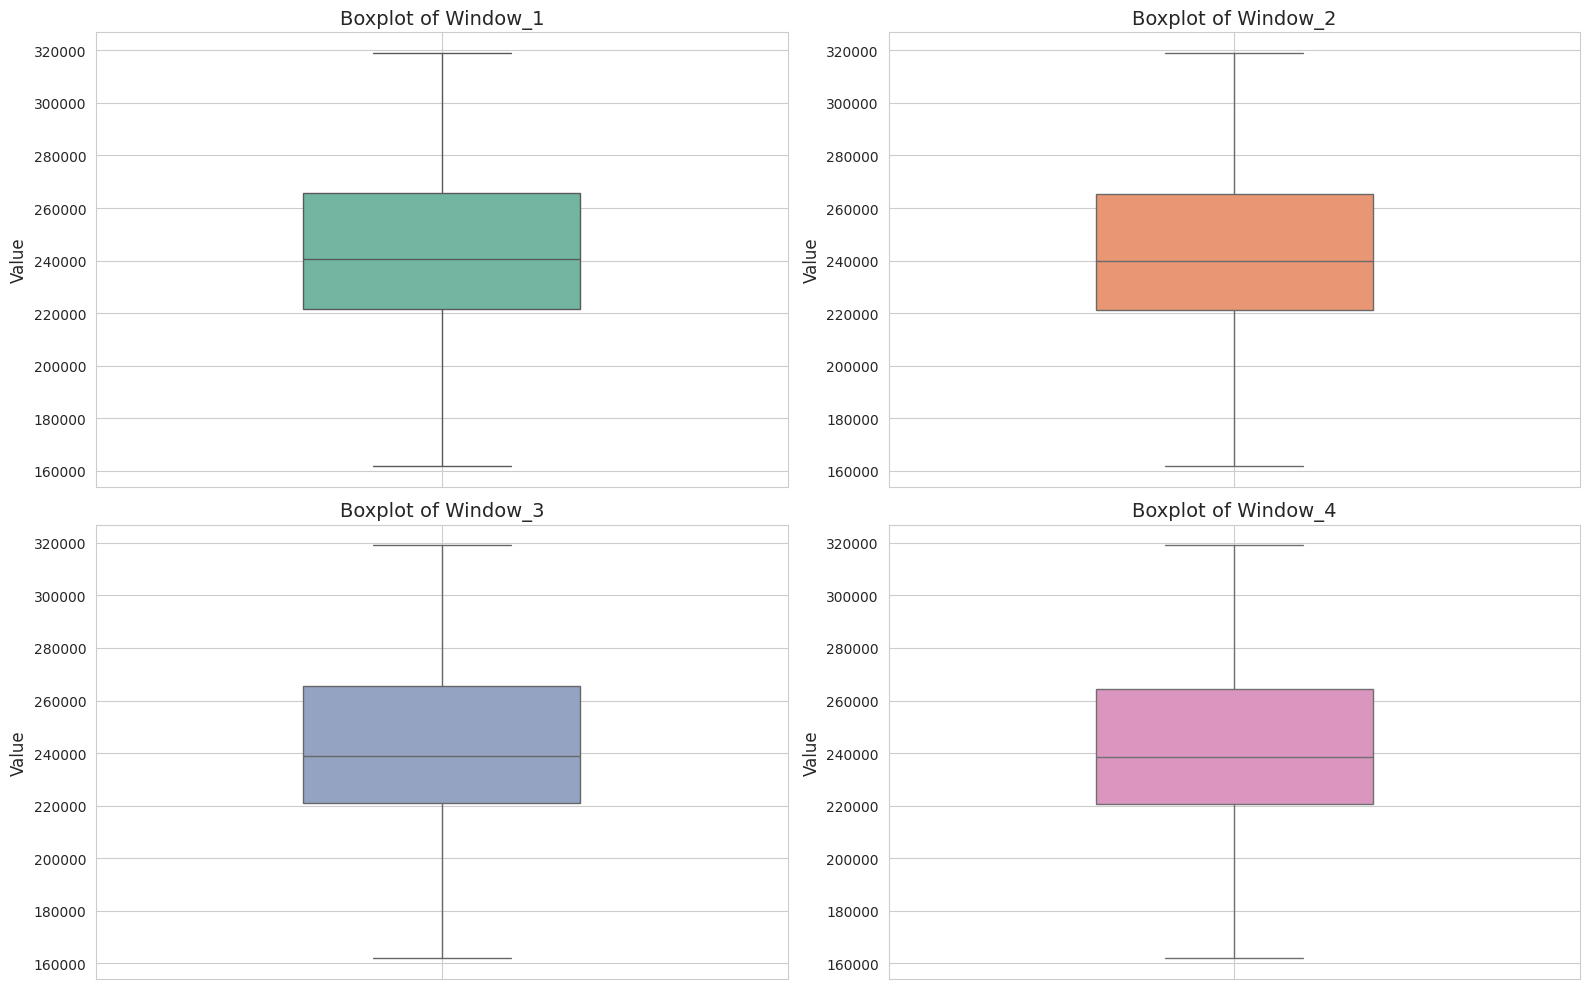

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Daftar kolom fitur yang akan digunakan
features = ['Window_1', 'Window_2', 'Window_3', 'Window_4']

# Mengatur ukuran figure
plt.figure(figsize=(16, 10))

# Menggunakan palet warna dari seaborn
colors = sb.color_palette("Set2", len(features))

# Membuat subplot untuk setiap fitur
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)

    # Membuat boxplot untuk tiap fitur
    sb.boxplot(data=df_sliding_windows[col], color=colors[i], width=0.4)

    # Memberikan judul yang jelas pada tiap plot
    plt.title(f'Boxplot of {col}', fontsize=14)

    # Memberikan label yang lebih jelas pada sumbu y
    plt.ylabel('Value', fontsize=12)

    # Menambahkan grid pada tiap plot untuk mempermudah pembacaan
    plt.grid(True)

# Menyesuaikan layout agar tidak terlalu padat
plt.tight_layout()

# Menampilkan plot
plt.show()


In [14]:
import numpy as np
import pandas as pd

# Menghitung IQR dan menghapus outlier
def remove_outliers(df, features):
    df_clean = df.copy()  # Membuat salinan agar data asli tidak terpengaruh

    for col in features:
        # Menghitung Q1, Q3 dan IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        # Menentukan batas untuk outlier
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Hapus outlier
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

# Fitur yang ingin dideteksi outlier dan dibersihkan
features = ['Window_1', 'Window_2', 'Window_3', 'Window_4']

# Menerapkan fungsi penghapusan outlier
df_slide_cleaned = remove_outliers(df_sliding_windows, features)

# Tampilkan data yang telah dibersihkan
print("Data yang telah dibersihkan dari outlier:")
print(df_slide_cleaned)


Data yang telah dibersihkan dari outlier:
          Window_1  Window_2  Window_3  Window_4
Date                                            
2009 04     317275    262339    303897    285934
2009 05     262339    303897    285934    281147
2009 06     303897    285934    281147    284093
2009 07     285934    281147    284093    287569
2009 08     281147    284093    287569    279111
...            ...       ...       ...       ...
2020 09     191919    183087    168406    161926
2020 10     183087    168406    161926    164494
2020 11     168406    161926    164494    168655
2020 12     161926    164494    168655    178597
2021 01     164494    168655    178597    181197

[142 rows x 4 columns]


#### normalisasi data

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Memuat dataset
data = load_iris()
X = data.data   # Fitur
y = data.target # Target

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom kecuali indeks
df_normalisasi = pd.DataFrame(scaler.fit_transform(df_slide_cleaned), columns=df_slide_cleaned.columns, index=df_slide_cleaned.index)
print(df_normalisasi)

          Window_1  Window_2  Window_3  Window_4
Date                                            
2009 04   0.989075  0.639309  0.903900  0.789533
2009 05   0.639309  0.903900  0.789533  0.759055
2009 06   0.903900  0.789533  0.759055  0.777812
2009 07   0.789533  0.759055  0.777812  0.799943
2009 08   0.759055  0.777812  0.799943  0.746092
...            ...       ...       ...       ...
2020 09   0.190959  0.134728  0.041257  0.000000
2020 10   0.134728  0.041257  0.000000  0.016350
2020 11   0.041257  0.000000  0.016350  0.042842
2020 12   0.000000  0.016350  0.042842  0.106141
2021 01   0.016350  0.042842  0.106141  0.122694

[142 rows x 4 columns]


### 3. Modeling

#### membagi data

In [16]:
from sklearn.model_selection import train_test_split

# Pastikan df_normalisasi sudah terdefinisi dan berisi data yang diperlukan

# Mengambil fitur (X) dengan menghapus kolom target (Window_1)
X_train_model = df_normalisasi.drop(columns=['Window_1'])

# Mengambil kolom target (y) yaitu Window_1
y_train_model = df_normalisasi['Window_1']

# Memisahkan data menjadi data latih dan data uji
# Menggunakan test_size=0.2 untuk 20% data sebagai data uji
# shuffle=False agar data tetap dalam urutan waktu (jika relevan)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_model,
    y_train_model,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

# Menampilkan ukuran dari data latih dan data uji untuk verifikasi
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (113, 3)
X_test shape: (29, 3)
y_train shape: (113,)
y_test shape: (29,)


 memiliki total 142 data poin dalam dataset awal (113 untuk pelatihan dan 29 untuk pengujian).
Pemisahan data dilakukan dengan proporsi 80% untuk pelatihan dan 20% untuk pengujian, yang merupakan praktik umum dalam pembelajaran mesin.

#### Membangun Model

##### Linear Regression

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Tampilkan hasil prediksi vs aktual
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print(results)


            Actual  Predicted
Date                         
2018 09   0.588018   0.530443
2018 10   0.539554   0.468248
2018 11   0.545825   0.433759
2018 12   0.419374   0.421417
2019 01   0.420520   0.411149
2019 02   0.409544   0.391311
2019 03   0.364906   0.268258
2019 04   0.460835   0.277106
2019 05   0.103976   0.341232
2019 06   0.307834   0.370363
2019 07   0.305810   0.368266
2019 08   0.377761   0.358898
2019 09   0.335129   0.339374
2019 10   0.338439   0.271672
2019 11   0.339649   0.214427
2019 12   0.207296   0.189335
2020 01   0.200980   0.264470
2020 02   0.080253   0.274896
2020 03   0.317773   0.228017
2020 04   0.233897   0.201725
2020 05   0.172757   0.139940
2020 06   0.211728   0.168032
2020 07   0.023302   0.208281
2020 08   0.170420   0.170384
2020 09   0.190959   0.101685
2020 10   0.134728   0.058754
2020 11   0.041257   0.060364
2020 12   0.000000   0.088136
2021 01   0.016350   0.129797


##### Random Forest

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Inisialisasi dan latih model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Tampilkan hasil prediksi vs aktual
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print(results)



            Actual  Predicted
Date                         
2018 09   0.588018   0.471638
2018 10   0.539554   0.459961
2018 11   0.545825   0.349835
2018 12   0.419374   0.356207
2019 01   0.420520   0.374956
2019 02   0.409544   0.398564
2019 03   0.364906   0.446123
2019 04   0.460835   0.438227
2019 05   0.103976   0.456368
2019 06   0.307834   0.445477
2019 07   0.305810   0.388026
2019 08   0.377761   0.434278
2019 09   0.335129   0.430955
2019 10   0.338439   0.439811
2019 11   0.339649   0.442069
2019 12   0.207296   0.444967
2020 01   0.200980   0.436532
2020 02   0.080253   0.439811
2020 03   0.317773   0.442069
2020 04   0.233897   0.442069
2020 05   0.172757   0.442069
2020 06   0.211728   0.442069
2020 07   0.023302   0.442069
2020 08   0.170420   0.442069
2020 09   0.190959   0.442069
2020 10   0.134728   0.442069
2020 11   0.041257   0.442069
2020 12   0.000000   0.442069
2021 01   0.016350   0.442069


##### LSTM

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - loss: 1.6682 - val_loss: 1.7228
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5420 - val_loss: 1.6705
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5101 - val_loss: 1.6153
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3844 - val_loss: 1.5553
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4406 - val_loss: 1.4876
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3508 - val_loss: 1.4108
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3588 - val_loss: 1.3224
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1692 - val_loss: 1.2210
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9937 - val_loss: 1.1071
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0560 - val_loss: 0.9782
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9139 - val_loss: 0.8382
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7360 - val_l

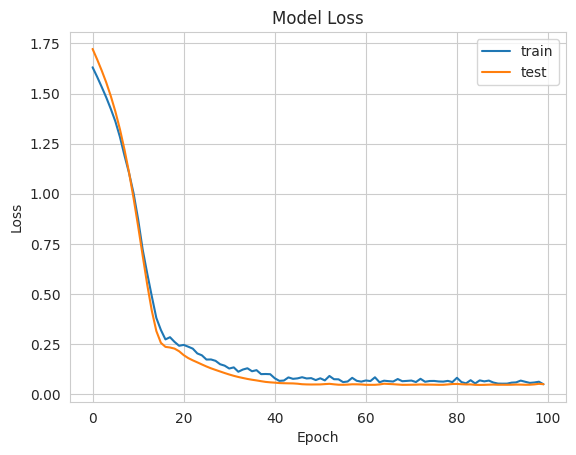

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Misalnya X dan y adalah dataset fitur dan target
# Bagi data menjadi 50% train dan 50% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skala data menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape input data for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Membangun model LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
history = model_lstm.fit(X_train_lstm, y_train, epochs=100, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=1)

# Make predictions
y_pred = model_lstm.predict(X_test_lstm)

# Flatten predictions for comparison
y_pred_flat = y_pred.flatten()

# # Evaluate the model
# mse = mean_squared_error(y_test, y_pred_flat)
# r2 = r2_score(y_test, y_pred_flat)

# print(f'Mean Squared Error: {mse}')
# print(f'R-squared: {r2}')

# # Function to calculate MAPE
# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# # Hitung MAPE
# mape = calculate_mape(y_test, y_pred_flat)
# print(f'MAPE: {mape:.2f}%')

# Plot training and validation loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


### 4. Bagging Ensemble Learning

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import matplotlib.pyplot as plt

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse
# Assuming df_normalized is already loaded
X = df_normalisasi[['Window_2', 'Window_3', 'Window_4']]
y = df_normalisasi['Window_1']  # Variabel target

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



#### regresi linier

In [21]:
# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

def calculate_log_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred))) * 100

# Hitung Log MAPE
log_mape = calculate_log_mape(y_test, y_pred)
print(f'Log MAPE: {log_mape:.2f}%')

Mean Squared Error: 0.012193946879073818
R-squared: 0.7108709775493947
Log MAPE: 5.93%


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
<ipython-input-38-af3cf37f9dbf>:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  predictions_df = pd.DataFrame(predictions, columns=['Predicted_Window_1'], index=pd.date_range(start='2021-02-01', periods=4, freq='M'))


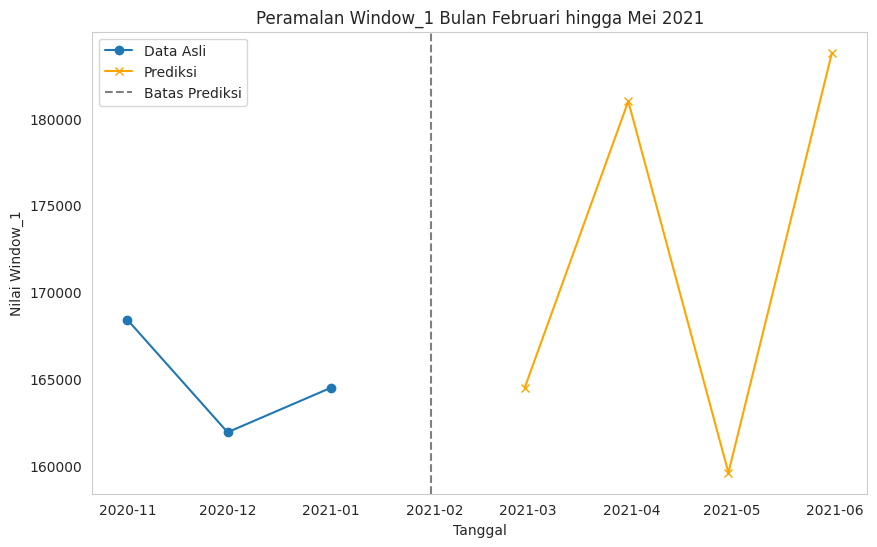

In [38]:
# Membuat DataFrame dari data yang diberikan
data = {
    'Year_Month': ['2020-11', '2020-12', '2021-01'],
    'Window_1': [168406, 161926, 164494],
    'Window_2': [161926, 164494, 168655],
    'Window_3': [164494, 168655, 178597],
    'Window_4': [168655, 178597, 181197],
}

df = pd.DataFrame(data)

# Mengatur index ke tahun dan bulan
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
df.set_index('Year_Month', inplace=True)

# Menyiapkan fitur dan target
X = df[['Window_2', 'Window_3', 'Window_4']]
y = df['Window_1']

# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X, y)

# Membuat DataFrame untuk menyimpan hasil prediksi
predictions = []

# Data untuk prediksi bulan berikutnya
last_window = df[['Window_2', 'Window_3', 'Window_4']].iloc[-1].values

# Prediksi bulan Februari hingga Mei 2021
for month in range(2, 6):  # Bulan 2 (Februari) sampai 5 (Mei)
    # Buat data baru untuk prediksi
    new_data = last_window.reshape(1, -1)
    predicted_value = model.predict(new_data)[0]

    # Simpan hasil prediksi
    predictions.append(predicted_value)

    # Update last_window untuk bulan berikutnya
    last_window = np.roll(last_window, -1)
    last_window[-1] = predicted_value

# Buat DataFrame untuk hasil prediksi
predictions_df = pd.DataFrame(predictions, columns=['Predicted_Window_1'], index=pd.date_range(start='2021-02-01', periods=4, freq='M'))

# Gabungkan data asli dan hasil prediksi untuk plotting
combined_df = pd.concat([df, predictions_df])

# Plot data asli dan hasil prediksi
plt.figure(figsize=(10, 6))
plt.plot(combined_df.index, combined_df['Window_1'], label='Data Asli', marker='o')
plt.plot(predictions_df.index, predictions_df['Predicted_Window_1'], label='Prediksi', marker='x', color='orange')
plt.title('Peramalan Window_1 Bulan Februari hingga Mei 2021')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Window_1')
plt.axvline(pd.to_datetime('2021-01-31'), color='gray', linestyle='--', label='Batas Prediksi')
plt.legend()
plt.grid()
plt.show()


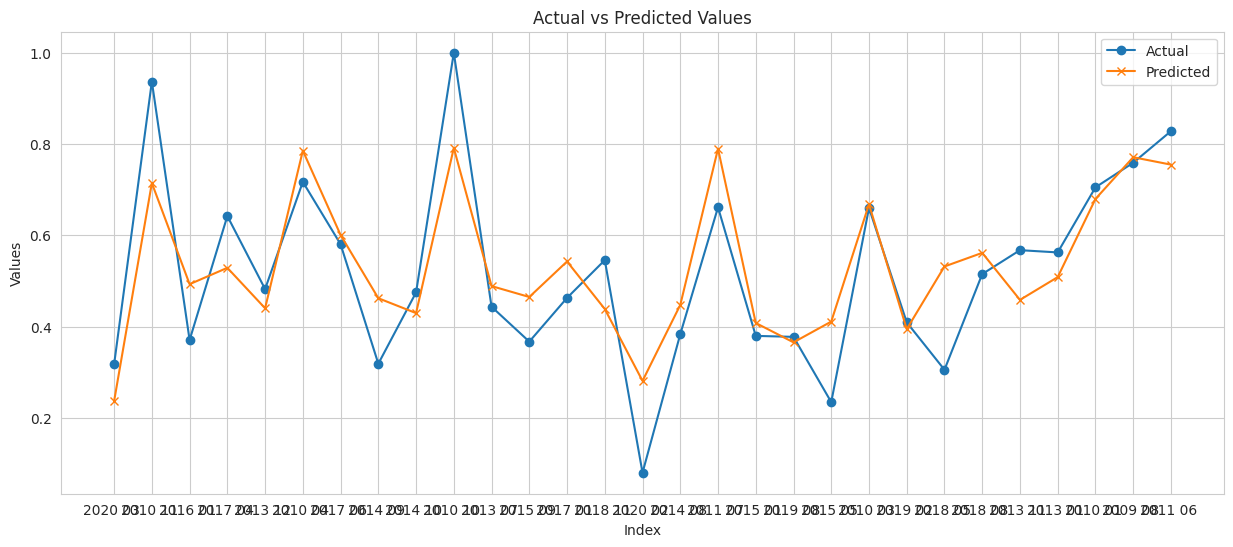

In [23]:
# Create a DataFrame to hold the actual vs predicted results
results_regresion = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plotting the Actual vs Predicted values
plt.figure(figsize=(15,6))
plt.plot(results_regresion.index, results_regresion['Actual'], label='Actual', marker='o')
plt.plot(results_regresion.index, results_regresion['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

#### random forest

In [24]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np

# # Inisialisasi dan latih model Random Forest
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

# # Prediksi pada data uji
# y_pred = model.predict(X_test)

# # Evaluasi model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f'Mean Squared Error: {mse}')
# print(f'R-squared: {r2}')

# # Function to calculate MAPE with handling zero values
# def calculate_mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     non_zero_indices = y_true != 0
#     return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

# # Hitung MAPE
# mape = calculate_mape(y_test, y_pred)
# print(f'MAPE: {mape:.2f}%')

# # Tampilkan hasil prediksi vs aktual (optional)
# # results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
# # print(results)


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Inisialisasi dan latih model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Function to calculate Logarithmic MAPE
def calculate_log_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Menggunakan log1p untuk menghindari log(0)
    return np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred))) * 100

# Hitung Log MAPE untuk Random Forest
log_mape = calculate_log_mape(y_test, y_pred)
print(f'Log MAPE: {log_mape:.2f}%')


Mean Squared Error: 0.014783710486354205
R-squared: 0.6494654435105254
Log MAPE: 6.75%


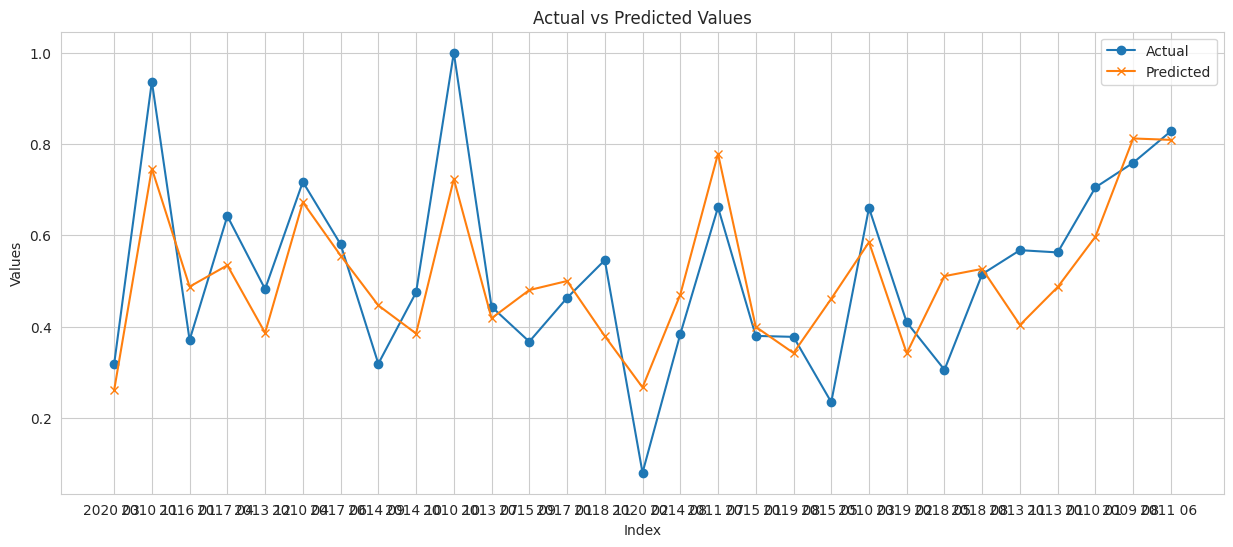

In [26]:
# Create a DataFrame to hold the actual vs predicted results
results_forest = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plotting the Actual vs Predicted values
plt.figure(figsize=(15,6))
plt.plot(results_forest.index, results_forest['Actual'], label='Actual', marker='o')
plt.plot(results_forest.index, results_forest['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

#### LSTM

In [27]:
# Mengubah bentuk data untuk LSTM (3D)
X_train_lstm = np.array(X_train).reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = np.array(X_test).reshape((X_test.shape[0], X_test.shape[1], 1))

# Model LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Melatih model LSTM
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)

# Prediksi menggunakan LSTM
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Menghitung Mean Squared Error (MSE)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)

# Menghitung R-squared
r2_lstm = r2_score(y_test, y_pred_lstm)

# Menampilkan hasil MSE dan R-squared
print(f'Mean Squared Error: {mse_lstm}')
print(f'R-squared: {r2_lstm}')

# Function to calculate Logarithmic MAPE (Log MAPE)
def calculate_log_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Menggunakan log1p untuk menghindari log(0)
    return np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred))) * 100

# Menghitung Log MAPE
log_mape_lstm = calculate_log_mape(y_test, y_pred_lstm)
print(f'Log MAPE: {log_mape_lstm:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Mean Squared Error: 0.13829233925496884
R-squared: -2.2790309206458987
Log MAPE: 23.53%


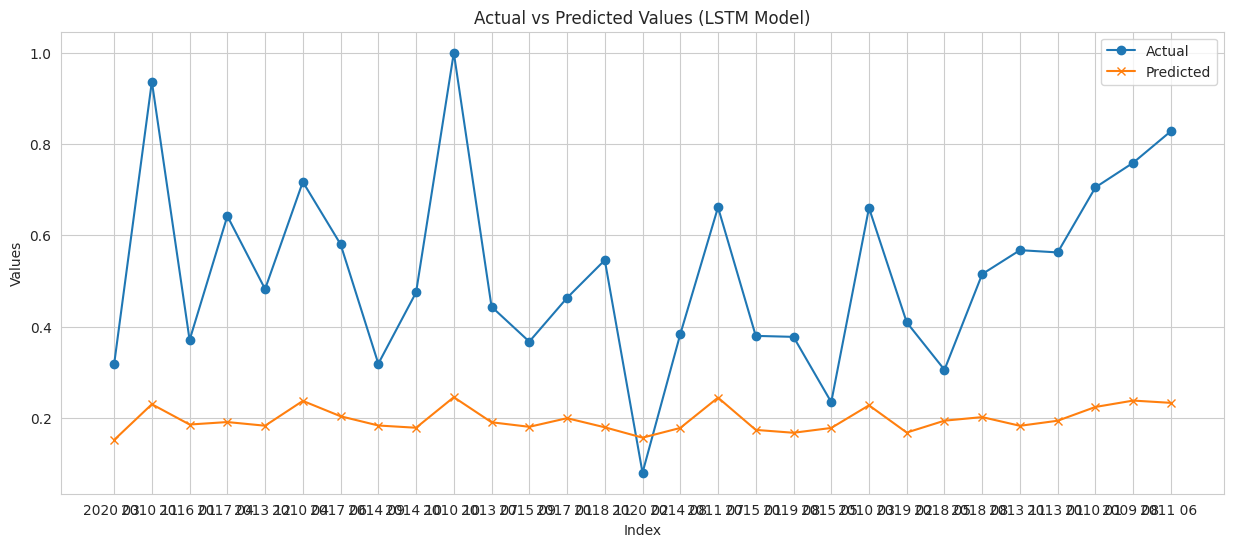

In [28]:
# Membuat DataFrame untuk menyimpan hasil aktual vs prediksi dari model LSTM
results_lstm = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lstm}, index=y_test.index)

# Plot nilai aktual vs prediksi
plt.figure(figsize=(15,6))
plt.plot(results_lstm.index, results_lstm['Actual'], label='Actual', marker='o')
plt.plot(results_lstm.index, results_lstm['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values (LSTM Model)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()


### exs

In [29]:
# # Menghasilkan lag 1, lag 2, dan lag 3
# df['lag_1'] = df['target'].shift(1)
# df['lag_2'] = df['target'].shift(2)
# df['lag_3'] = df['target'].shift(3)


In [30]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 38.5 MB/s eta 0:00:00


In [31]:
!pip install pyreadstat scikit-learn

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pyreadstat
from IPython.display import FileLink

# Membuat model regresi linier
model = LinearRegression()
model.fit(X_train, y_train)

# Menyimpan hasil prediksi ke DataFrame
# Convert the 'data' dictionary to a pandas DataFrame
data = pd.DataFrame(data) # This line converts the dictionary to DataFrame

data['predictions'] = model.predict(X)

# Menyimpan dataset ke format .sav
output_file = 'regression_results.sav'
pyreadstat.write_sav(data, output_file)

# Menampilkan tautan unduhan
display(FileLink(output_file))

/content/regression_results.sav

In [34]:
import pandas as pd
import pyreadstat
from IPython.display import FileLink

# Menyimpan koefisien dan intercept model ke dalam DataFrame
scalars = {
    'Coefficient': model.coef_[0],  # Koefisien regresi (hanya satu jika satu fitur)
    'Intercept': model.intercept_   # Intercept regresi
}

# Membuat DataFrame dari scalar
scalars_df = pd.DataFrame([scalars])

# Menyimpan scalar ke dalam file .sav
output_file = 'regression_scalars.sav'
pyreadstat.write_sav(scalars_df, output_file)

# Menampilkan tautan unduhan
display(FileLink(output_file))


/content/regression_scalars.sav

In [35]:
import pyreadstat

# Menyimpan dataset ke dalam format .sav
output_file = 'processed_data.sav'
pyreadstat.write_sav(data, output_file)

# Mengunduh file dari notebook (untuk Google Colab atau Jupyter Notebook)
from IPython.display import FileLink
display(FileLink(output_file))


/content/processed_data.sav